<a href="https://colab.research.google.com/github/ChayatornOunpat/2190512-Application-Development/blob/master/Week02_exercise_using_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question:** When should we go out for exercise?

Download pm25.csv from https://drive.google.com/file/d/1Ry1GuKrCho_VpUT2jAkNjhrqfQo2qp_B/view

Upload `pm25.csv` as runtime file to Collab session storage. This runtime file will be erased when runtime is terminated.

Explore pandas library API at [link text](https://pandas.pydata.org/docs/reference/index.html#api).


## Data Loading
**`read_csv`** Read a comma-separated values (csv) file into `DataFrame`. Giving filepath or URL.
Frequently used optional parameters
*   `sep` : Character or regex pattern to treat as the delimiter. Default ','
*   `header` : Value representing the heading row. Possible values include `int` (e.g. `header=0`), Sequence of `int`, `'infer'` or `'None'`. Default value is `'infer'` which infer the column names, which is from the first line of the file.

**`DataFrame`** is primary pandas data structure, as two-dimensional, size-mutable, potentially heterogeneous tabular data. It contains labeled axes (rows and columns). Arithmetic operations align on both row and column labels.


In [11]:
import pandas

df = pandas.read_csv("./pm25.csv", header=None)

**`DataFrame.head(n=5)`** returns the first `n` rows for the object based on position.
*   `n` : Number of rows to return. Default is 5




In [12]:
df.head(5)

,0,1
0,2018-12-01 00:00:00,42
1,2018-12-01 01:00:00,44
2,2018-12-01 02:00:00,38
3,2018-12-01 03:00:00,40
4,2018-12-01 04:00:00,38


**`DataFrame.columns`** = column labels of the DataFrame

In [13]:
df.columns

Index([0, 1], dtype='int64')

## Data Series

Extract data series from data frame.

Use `dataFrame.label` or `dataFrame['label']`to access data series of corresponding column label.

In [14]:
df[0]

0       2018-12-01 00:00:00
1       2018-12-01 01:00:00
2       2018-12-01 02:00:00
3       2018-12-01 03:00:00
4       2018-12-01 04:00:00
               ...         
1309    2019-01-24 13:00:00
1310    2019-01-24 14:00:00
1311    2019-01-24 15:00:00
1312    2019-01-24 16:00:00
1313    2019-01-24 17:00:00
Name: 0, Length: 1314, dtype: str

Slice the data for only those that match the given condition. The result is a data frame.

Original data types for both dt and pm columns are String.

**`pandas.to_datetime(arg)`** converts argument to datetime.

*   `dayfirst`: `bool`, If `True`, parses dates with the day first (default is `False`)
*   `yearfirst` : `bool`, If `True`, parses dates with the year first (default `False`)




In [15]:
df[0] = pandas.to_datetime(df[0])
df

,0,1
0,2018-12-01 00:00:00,42
1,2018-12-01 01:00:00,44
2,2018-12-01 02:00:00,38
3,2018-12-01 03:00:00,40
4,2018-12-01 04:00:00,38
...,...,...
1309,2019-01-24 13:00:00,-
1310,2019-01-24 14:00:00,-
1311,2019-01-24 15:00:00,-
1312,2019-01-24 16:00:00,-


Create a new data frame `filtered_df` that stores sliced data from `df` for only those with `pm!='-'`

In [17]:
df = df[df[1] != "-"]
df

,0,1
0,2018-12-01 00:00:00,42
1,2018-12-01 01:00:00,44
2,2018-12-01 02:00:00,38
3,2018-12-01 03:00:00,40
4,2018-12-01 04:00:00,38
...,...,...
1304,2019-01-24 08:00:00,46
1305,2019-01-24 09:00:00,46
1306,2019-01-24 10:00:00,40
1307,2019-01-24 11:00:00,40


**`pandas.to_numeric(arg)`** convert argument to a numeric type. The default return dtype is `float64` or `int64` depending on the data supplied.

In [18]:
df[1] = pandas.to_numeric(df[1])
df

,0,1
0,2018-12-01 00:00:00,42
1,2018-12-01 01:00:00,44
2,2018-12-01 02:00:00,38
3,2018-12-01 03:00:00,40
4,2018-12-01 04:00:00,38
...,...,...
1304,2019-01-24 08:00:00,46
1305,2019-01-24 09:00:00,46
1306,2019-01-24 10:00:00,40
1307,2019-01-24 11:00:00,40


**`.dt`** **accessor** in pandas briefly and clearly returns datetime like properties for the values of the series, if it is a datetime/period like Series.

You may obtain the `year`, `month`, `day`, `dayofweek`, `hour`, `minute`, `second` components of the ISO year.


In [22]:
df[0].dt.hour

0        0
1        1
2        2
3        3
4        4
        ..
1304     8
1305     9
1306    10
1307    11
1308    12
Name: 0, Length: 1278, dtype: int32

## Visualize Data Using Pandas
**`Series.plot(*args, **kwargs)`** or **`DataFrame.plot(*args, **kwargs)`** makes plots of Series or DataFrame
*   `figsize` : tuple (`width`, `height`) in inches
*   `title` : Title to use for the plot.
*   `xlabel` : Name to use for the xlabel on x-axis. Default uses index name.
*   `ylabel` : Name to use for the ylabel on y-axis. Default shows no ylabel.
*   `x` : label or position. Only used if data is a DataFrame.
*   `y` : label, position or list of label, positions. Allows plotting of one column versus another. Only used if data is a DataFrame.
*   `y` : Name to use for the ylabel on y-axis. Default shows no ylabel.
*   `**kwargs` : Options to pass to matplotlib plotting method



<Axes: >

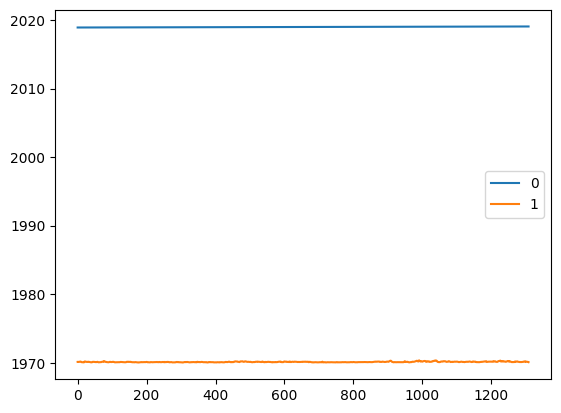

In [24]:
df.plot()

**`DataFrame.set_index(keys, *, drop=True, append=False, inplace=False, verify_integrity=False)`** set the DataFrame index (row labels) using one or more existing columns or arrays (of the correct length). The index can replace the existing index or expand on it.
*   `keys` : either a single column key (label), a single array of the same length as the calling DataFrame, or a list containing an arbitrary combination of column keys and arrays
*   `drop` : If `True`, delete columns to be used as the new index. Default is `True`.
*   `append` : If `True`, append columns to existing index. Default is `False`.
*   `inplace` : If `True`, modify the DataFrame rather than creating a new one. Default is `False`.
*   `verify_integrity` : If `True`, check the new index for duplicates. Otherwise defer the check until necessary. Default is `False`.



In [32]:
df.set_index(pandas.Series(range(1, len(df) + 1)), inplace=True)
df

,0,1
1,2018-12-01 00:00:00,42
2,2018-12-01 01:00:00,44
3,2018-12-01 02:00:00,38
4,2018-12-01 03:00:00,40
5,2018-12-01 04:00:00,38
...,...,...
1274,2019-01-24 08:00:00,46
1275,2019-01-24 09:00:00,46
1276,2019-01-24 10:00:00,40
1277,2019-01-24 11:00:00,40


**`Series.hist(by=None, ax=None, grid=True, xlabelsize=None, xrot=None, ylabelsize=None, yrot=None, figsize=None, bins=10, backend=None, legend=False, **kwargs)`** draws histogram of the input series using matplotlib, Grouping data into "bins" of equal width for specified number of bins. Bar length represents data points are in that bin.

*   `bins` : Number of histogram bins to be used.
*   List item



<Axes: >

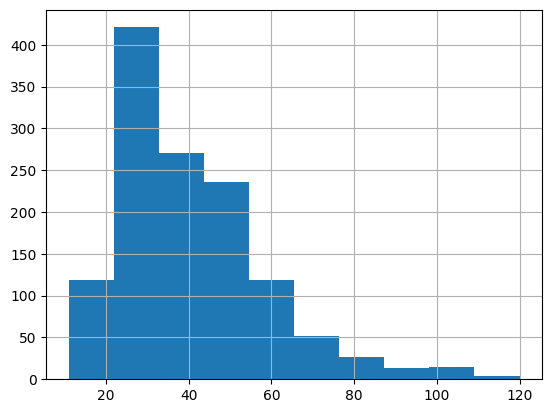

In [33]:
df[1].hist()

**`pandas.DataFrame.groupby()`** and **`pandas.Series.groupby()`** creates `DataFrameGroupBy` object.

In [45]:
df[2] = df[0].dt.hour
ndf = df.groupby(2)[1].sum()
ndf

2
0     2403
1     2348
2     2239
3     2250
4     2204
5     2321
6     2484
7     2375
8     2399
9     2343
10    2204
11    2057
12    1896
13    1695
14    1782
15    1755
16    1771
17    1808
18    1734
19    2013
20    2204
21    2328
22    2467
23    2427
Name: 1, dtype: int64

**`Series.apply(func, convert_dtype=<no_default>, args=(), *, by_row='compat', **kwargs)`** invokes function on values of Series. It can be `ufunc` (a NumPy function that applies to the entire Series) or a Python function that only works on single values.
*   `func` : Python function or NumPy ufunc to apply
*   `args` : tuple of positional arguments passed to func after the series value.



In [46]:
ndf = ndf.apply(lambda x: x*10)
ndf

2
0     24030
1     23480
2     22390
3     22500
4     22040
5     23210
6     24840
7     23750
8     23990
9     23430
10    22040
11    20570
12    18960
13    16950
14    17820
15    17550
16    17710
17    18080
18    17340
19    20130
20    22040
21    23280
22    24670
23    24270
Name: 1, dtype: int64

**`pandas.pivot_table(data, values=None, index=None, columns=None, aggfunc='mean', fill_value=None, margins=False, dropna=True, margins_name='All', observed=<no_default>, sort=True)`** creates a spreadsheet-style pivot table as a DataFrame. The levels in the pivot table will be stored in MultiIndex objects (hierarchical indexes) on the index and columns of the result DataFrame.
*   `data` : DataFrame
*   `index` : Keys to group by on the pivot table index (column, Grouper, array, or list of the previous).
*   `columns` : Keys to group by on the pivot table column (column, Grouper, array, or list of the previous).
*   `aggfunc` : Aggregation function. If a dict is passed, the key is column to aggregate and the value is function or list of functions. If a list of functions is passed, the resulting pivot table will have hierarchical columns whose top level are the function names.

